In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
scheme = pd.read_csv("../data/processed/07_scheme_performance.csv")

nav = pd.read_csv("../data/processed/02_nav_history.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

In [4]:
scheme.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [5]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [7]:
print("Scheme:", scheme.shape)
print("NAV:", nav.shape)
print("Benchmark:", benchmark.shape)

Scheme: (40, 19)
NAV: (46000, 3)
Benchmark: (8050, 3)


In [8]:
scheme.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [9]:
scheme.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [10]:
top_5yr = (
    scheme.sort_values(
        by='return_5yr_pct',
        ascending=False
    )
    [['scheme_name','fund_house','return_5yr_pct']]
    .head(10)
)

top_5yr

,scheme_name,fund_house,return_5yr_pct
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,23.80
27,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,22.62
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,21.88
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,21.82
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,20.67
39,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,20.61
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,19.00
26,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,18.94
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,17.75
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,17.69


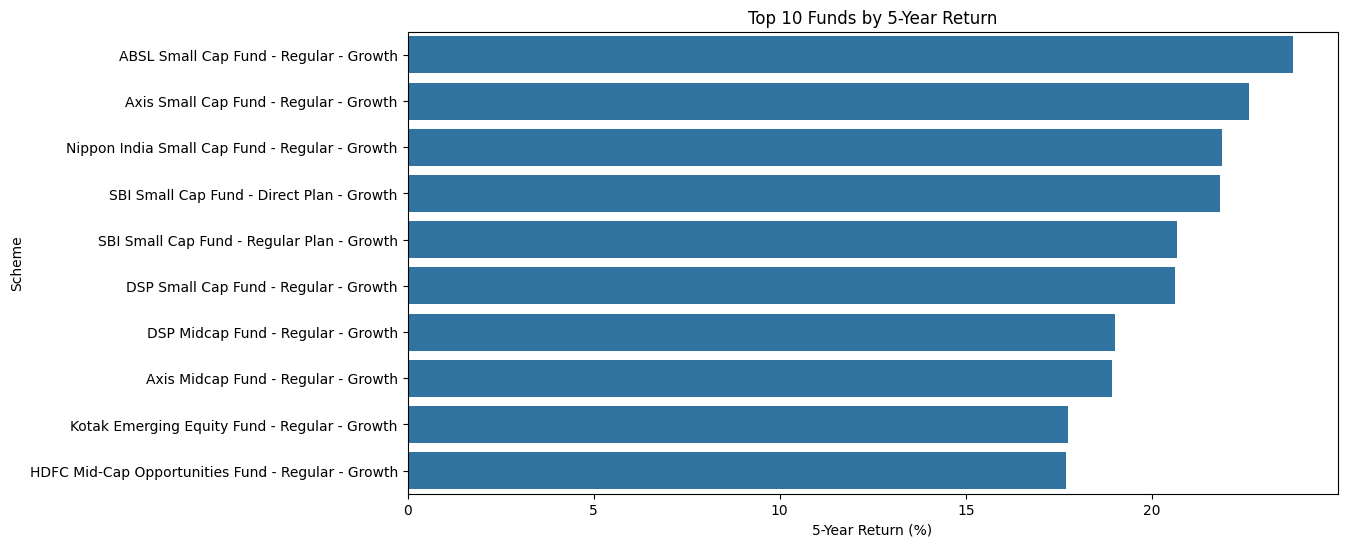

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_5yr,
    x='return_5yr_pct',
    y='scheme_name'
)

plt.title("Top 10 Funds by 5-Year Return")
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme")

plt.show()

In [12]:
top_sharpe = (
    scheme.sort_values(
        by='sharpe_ratio',
        ascending=False
    )
    [['scheme_name','sharpe_ratio']]
    .head(10)
)

top_sharpe

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


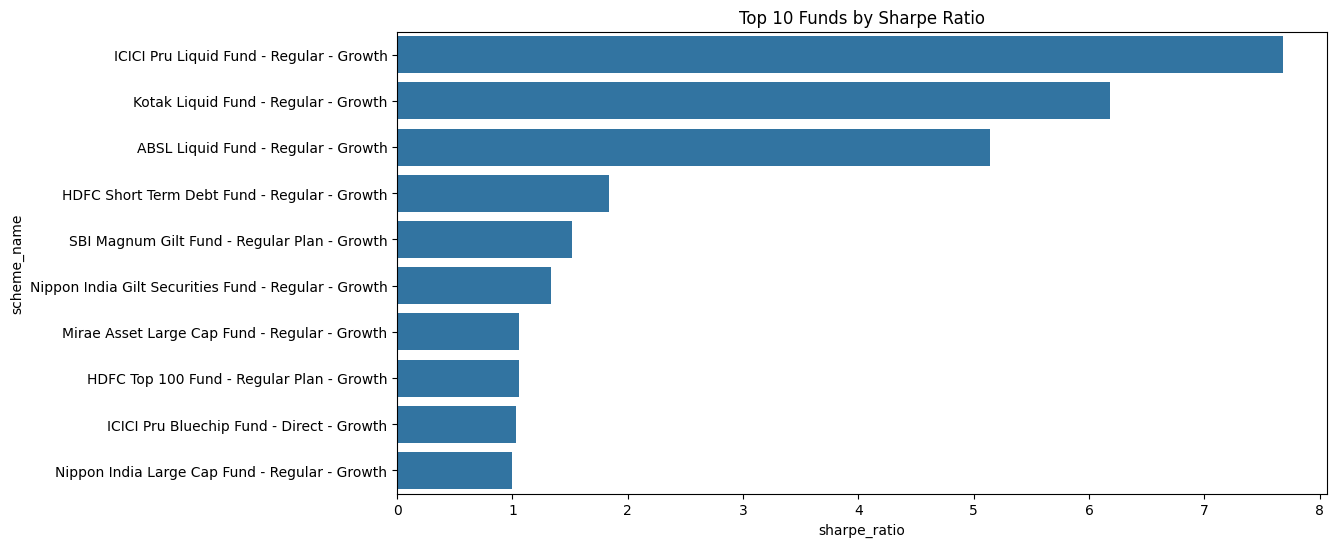

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x='sharpe_ratio',
    y='scheme_name'
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.show()

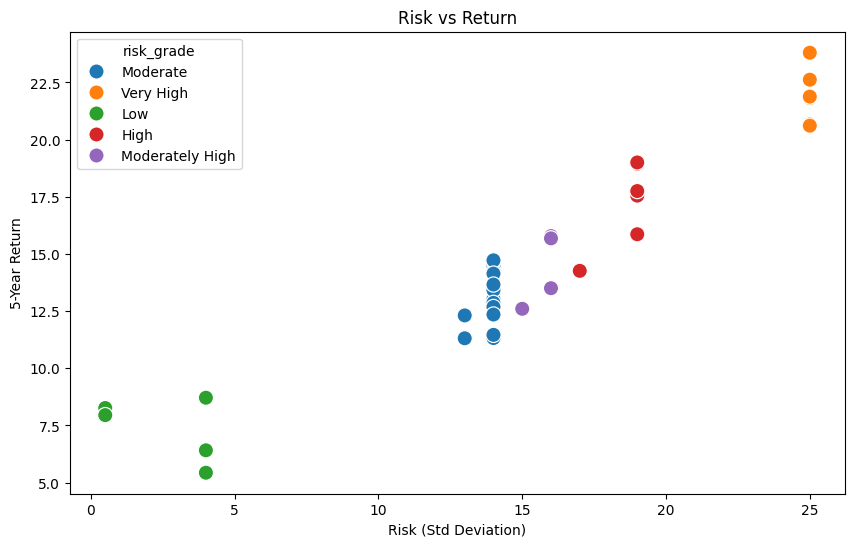

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=scheme,
    x='std_dev_ann_pct',
    y='return_5yr_pct',
    hue='risk_grade',
    s=120
)

plt.title("Risk vs Return")
plt.xlabel("Risk (Std Deviation)")
plt.ylabel("5-Year Return")

plt.show()

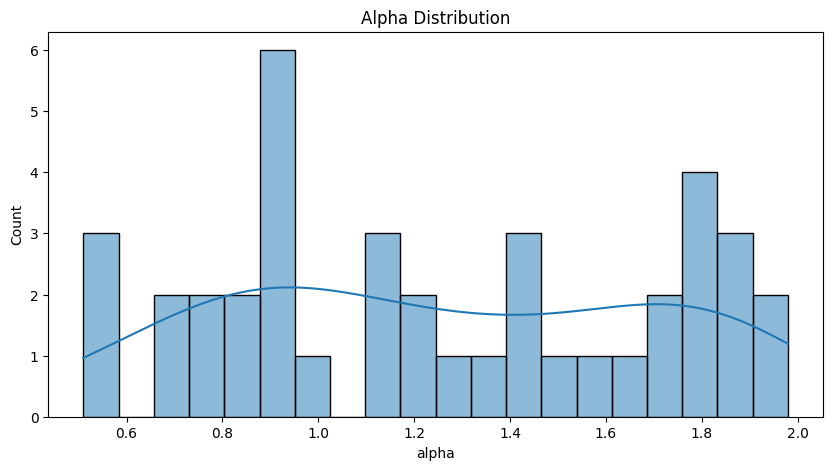

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    scheme['alpha'],
    bins=20,
    kde=True
)

plt.title("Alpha Distribution")

plt.show()

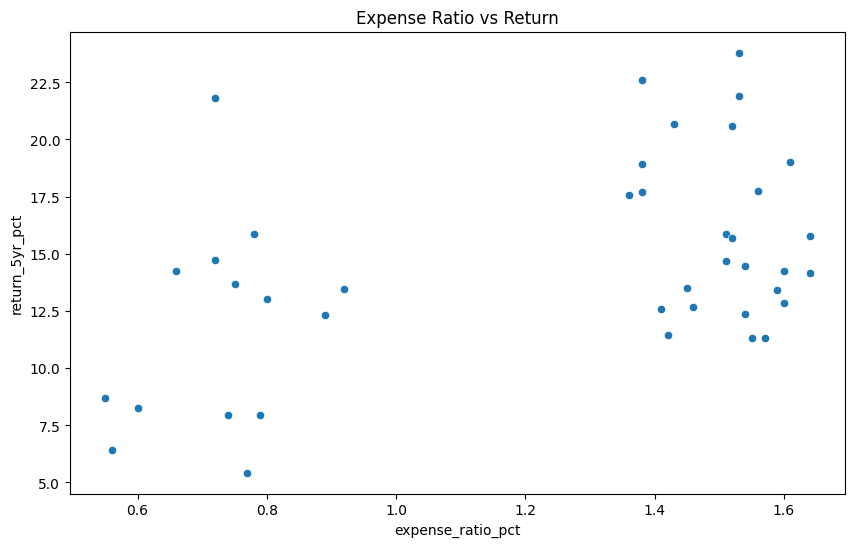

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=scheme,
    x='expense_ratio_pct',
    y='return_5yr_pct'
)

plt.title("Expense Ratio vs Return")

plt.show()

In [18]:
scheme['risk_grade'].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

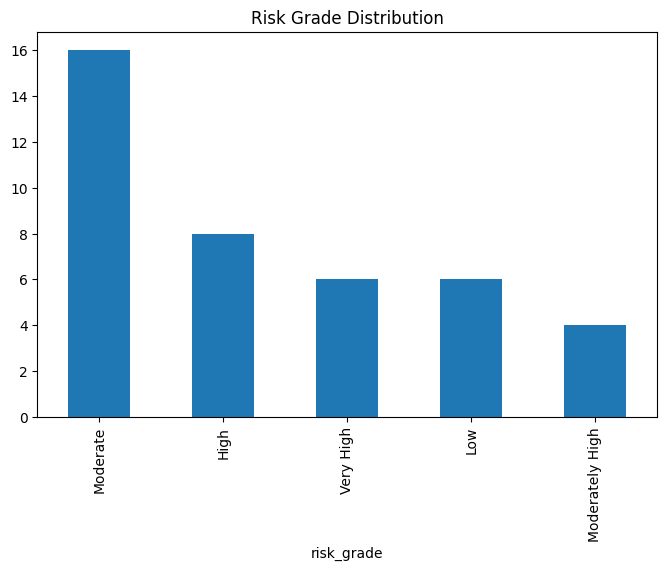

In [19]:
plt.figure(figsize=(8,5))

scheme['risk_grade'].value_counts().plot(
    kind='bar'
)

plt.title("Risk Grade Distribution")

plt.show()

In [20]:
scheme.shape

(40, 19)

In [21]:
scheme[['scheme_name','return_5yr_pct']].head()

,scheme_name,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.43


In [22]:
top_5yr = (
    scheme.sort_values(
        by='return_5yr_pct',
        ascending=False
    )
    [['scheme_name','fund_house','return_5yr_pct']]
    .head(10)
)

top_5yr

,scheme_name,fund_house,return_5yr_pct
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,23.80
27,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,22.62
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,21.88
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,21.82
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,20.67
39,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,20.61
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,19.00
26,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,18.94
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,17.75
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,17.69


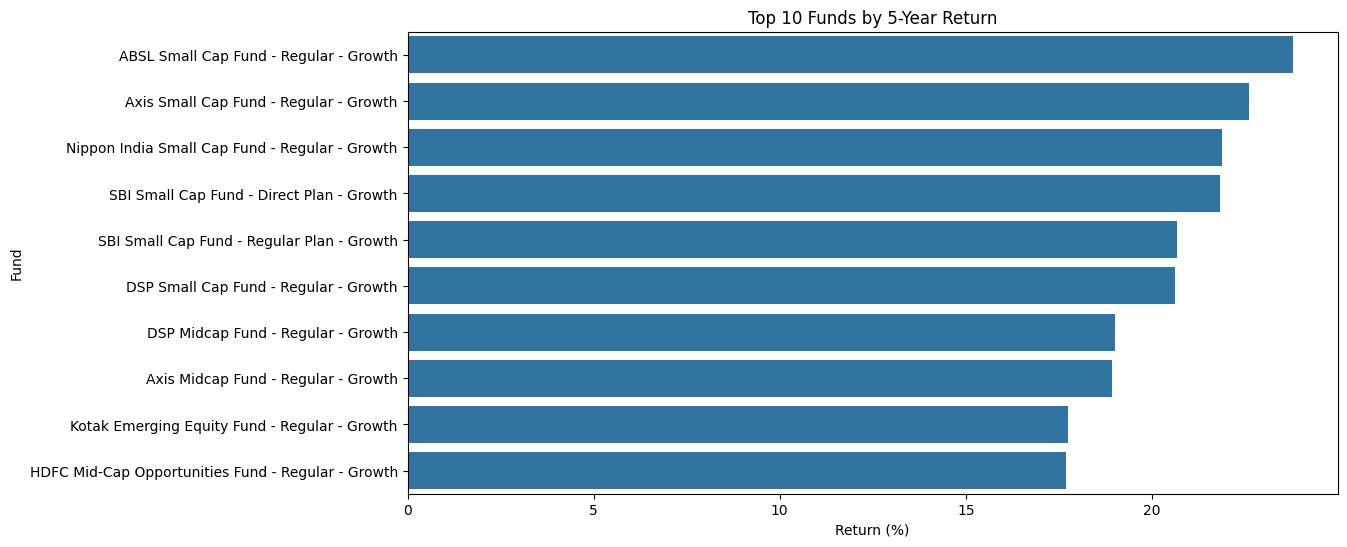

In [23]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_5yr,
    x='return_5yr_pct',
    y='scheme_name'
)

plt.title("Top 10 Funds by 5-Year Return")
plt.xlabel("Return (%)")
plt.ylabel("Fund")

plt.show()

In [24]:
top_sharpe = (
    scheme.sort_values(
        by='sharpe_ratio',
        ascending=False
    )
    [['scheme_name','sharpe_ratio']]
    .head(10)
)

top_sharpe

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


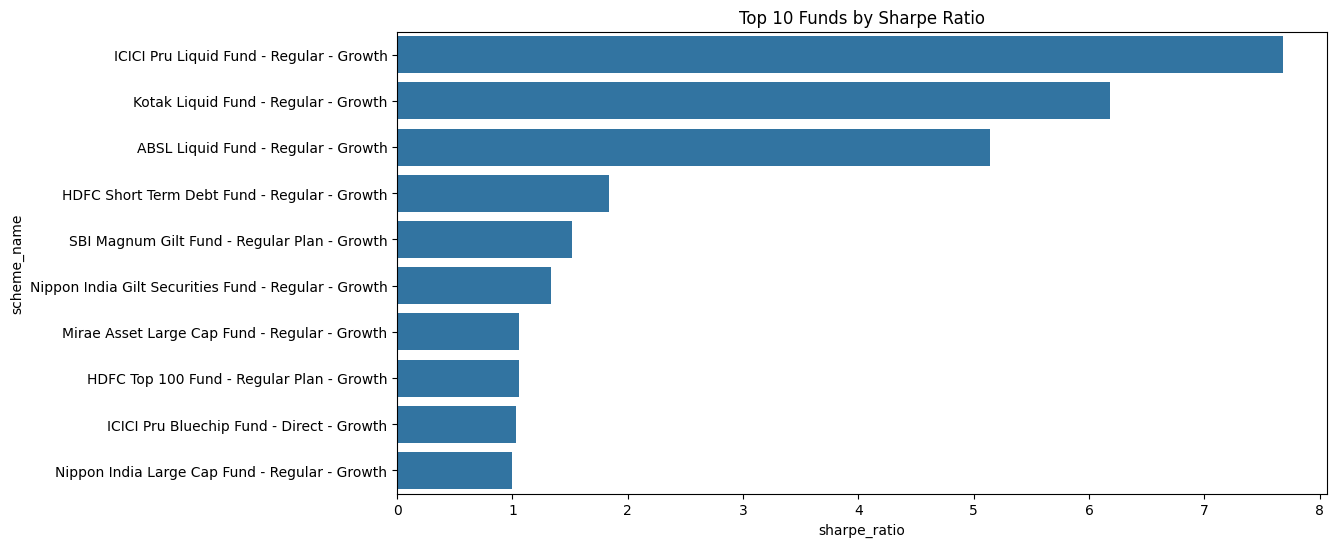

In [25]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x='sharpe_ratio',
    y='scheme_name'
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.show()

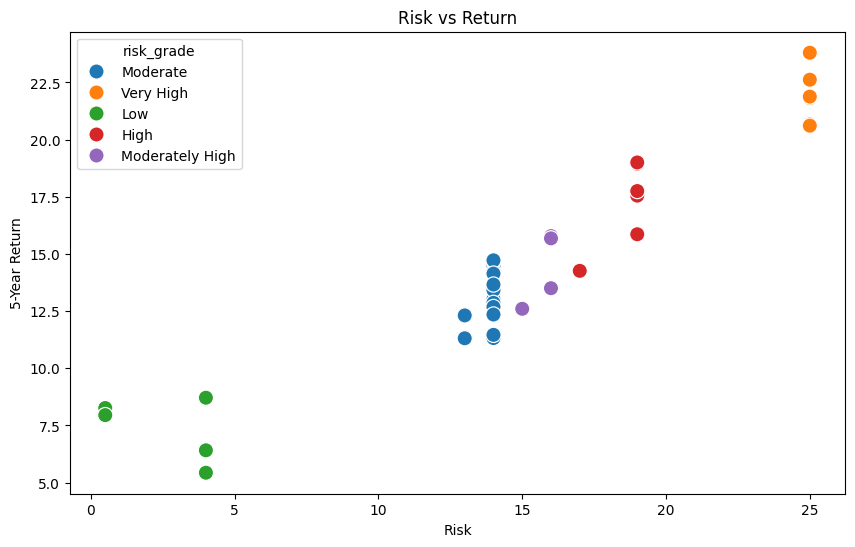

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=scheme,
    x='std_dev_ann_pct',
    y='return_5yr_pct',
    hue='risk_grade',
    s=120
)

plt.title("Risk vs Return")
plt.xlabel("Risk")
plt.ylabel("5-Year Return")

plt.show()

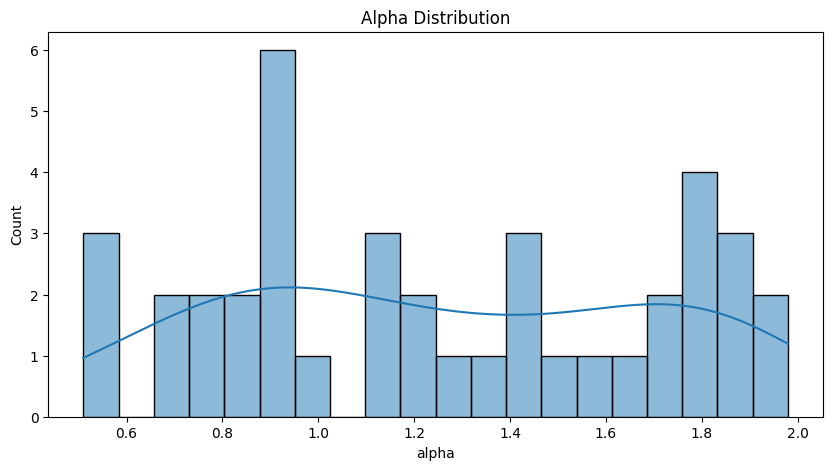

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    scheme['alpha'],
    bins=20,
    kde=True
)

plt.title("Alpha Distribution")

plt.show()

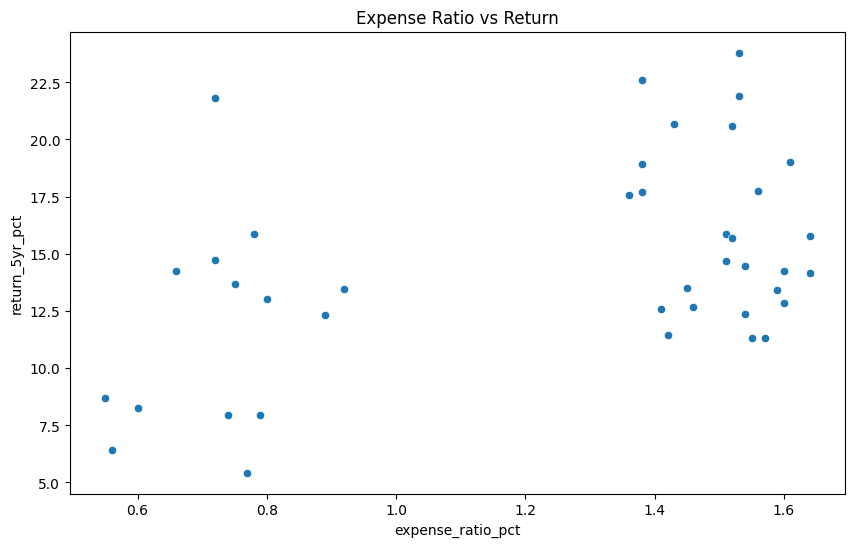

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=scheme,
    x='expense_ratio_pct',
    y='return_5yr_pct'
)

plt.title("Expense Ratio vs Return")

plt.show()

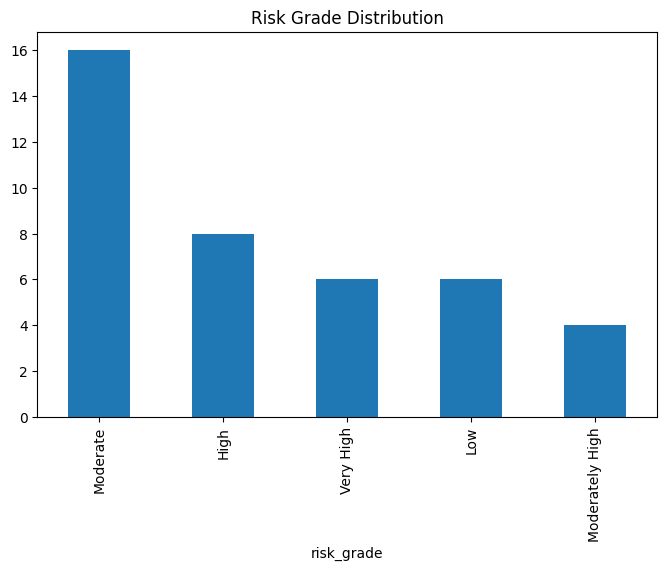

In [29]:
plt.figure(figsize=(8,5))

scheme['risk_grade'].value_counts().plot(
    kind='bar'
)

plt.title("Risk Grade Distribution")

plt.show()